Use of Capital Table:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Use_of_Capital    8 non-null      object 
 1   Amount            8 non-null      int64  
 2   Percent_of_Total  8 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 324.0+ bytes
None
              Amount  Percent_of_Total
count       8.000000          8.000000
mean    86875.000000         12.500000
std     98703.650967         14.201964
min      5000.000000          0.719424
25%     13750.000000          1.978417
50%     57500.000000          8.273381
75%    122500.000000         17.625899
max    300000.000000         43.165468

Startup Expenses Table:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  

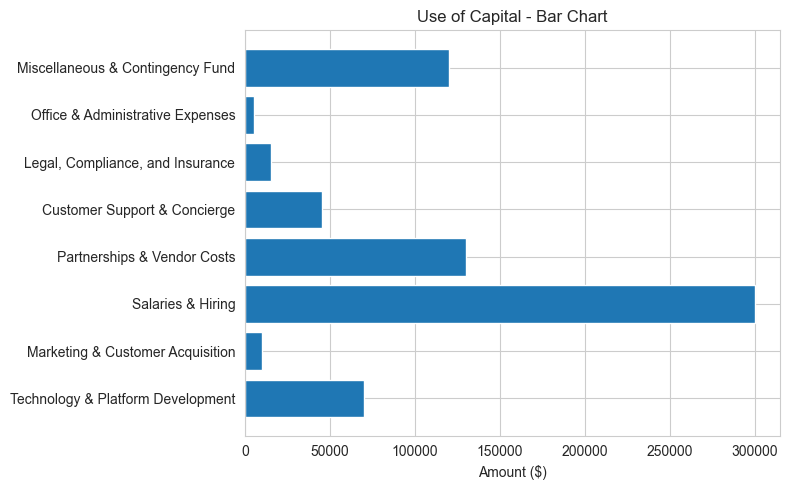

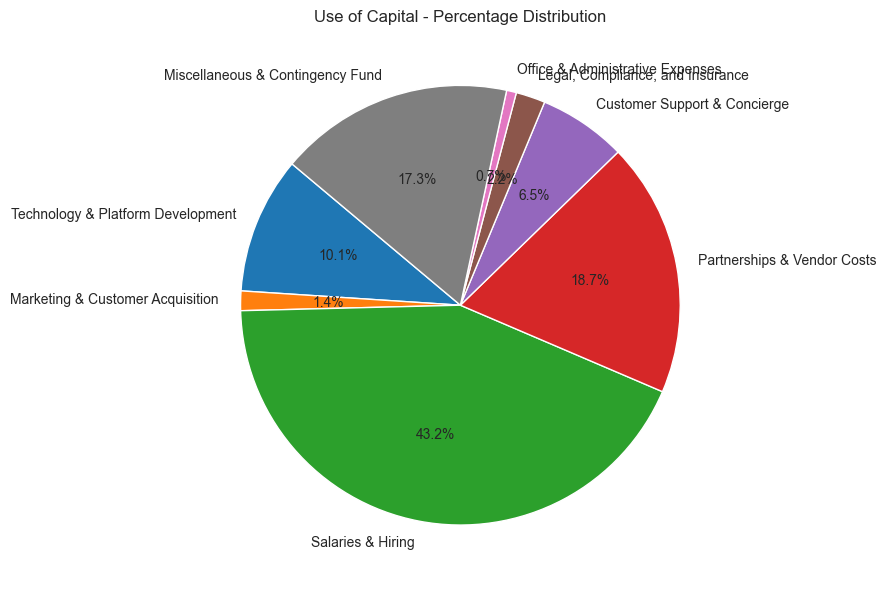

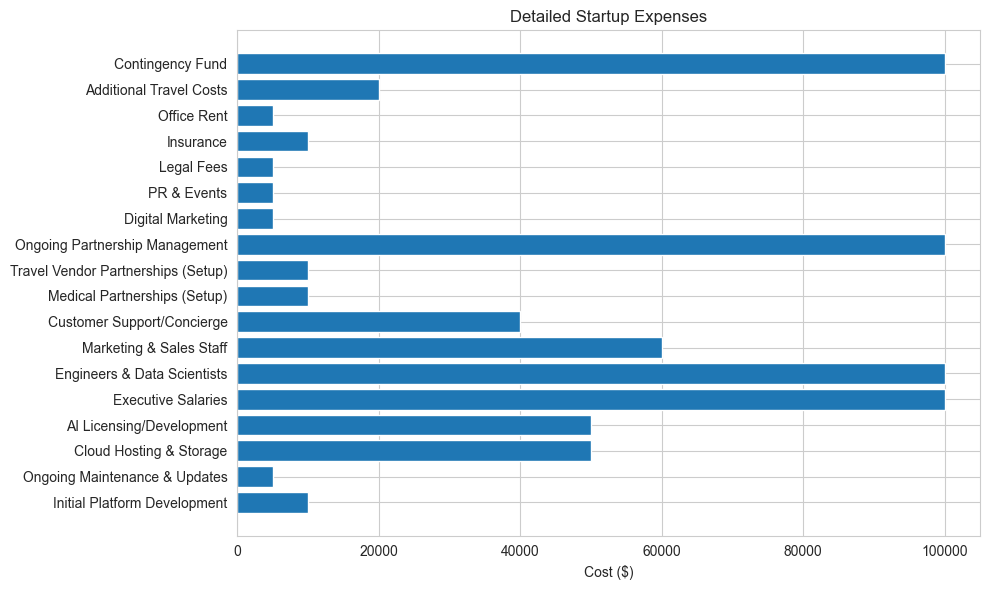

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. 构造 Table ---
use_of_capital = {
    "Use_of_Capital": [
        "Technology & Platform Development",
        "Marketing & Customer Acquisition",
        "Salaries & Hiring",
        "Partnerships & Vendor Costs",
        "Customer Support & Concierge",
        "Legal, Compliance, and Insurance",
        "Office & Administrative Expenses",
        "Miscellaneous & Contingency Fund"
    ],
    "Amount": [
        70000,
        10000,
        300000,
        130000,
        45000,
        15000,
        5000,
        120000
    ]
}

startup_expenses = {
    "Expense_Item": [
        "Initial Platform Development",
        "Ongoing Maintenance & Updates",
        "Cloud Hosting & Storage",
        "AI Licensing/Development",
        "Executive Salaries",
        "Engineers & Data Scientists",
        "Marketing & Sales Staff",
        "Customer Support/Concierge",
        "Medical Partnerships (Setup)",
        "Travel Vendor Partnerships (Setup)",
        "Ongoing Partnership Management",
        "Digital Marketing",
        "PR & Events",
        "Legal Fees",
        "Insurance",
        "Office Rent",
        "Additional Travel Costs",
        "Contingency Fund"
    ],
    "Cost": [
        10000,
         5000,
        50000,
        50000,
        100000,
        100000,
        60000,
        40000,
        10000,
        10000,
        100000,
         5000,
         5000,
         5000,
        10000,
         5000,
        20000,
        100000
    ]
}

df_use = pd.DataFrame(use_of_capital)
df_exp = pd.DataFrame(startup_expenses)

# Add totals
df_use["Percent_of_Total"] = df_use["Amount"] / df_use["Amount"].sum() * 100
df_exp["Percent_of_Total"] = df_exp["Cost"] / df_exp["Cost"].sum() * 100

# --- 2. 数据检查 ---
print("Use of Capital Table:")
print(df_use.info())
print(df_use.describe())

print("\nStartup Expenses Table:")
print(df_exp.info())
print(df_exp.describe())

# Check for missing values
print("\nMissing in Use of Capital:", df_use.isna().sum().sum())
print("Missing in Startup Expenses:", df_exp.isna().sum().sum())

# --- 3. 可视化 ---
plt.figure(figsize=(8,5))
plt.barh(df_use["Use_of_Capital"], df_use["Amount"])
plt.title("Use of Capital - Bar Chart")
plt.xlabel("Amount ($)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.pie(df_use["Amount"], labels=df_use["Use_of_Capital"],
        autopct='%1.1f%%', startangle=140)
plt.title("Use of Capital - Percentage Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.barh(df_exp["Expense_Item"], df_exp["Cost"])
plt.title("Detailed Startup Expenses")
plt.xlabel("Cost ($)")
plt.tight_layout()
plt.show()


part2


In [28]:
# Visualization including US & Canada (procedure-only baseline)
# Goal: show sponsor advantage via cross-country procedure cost arbitrage

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Construct procedure-level cost ranges (no travel for US/Canada)
# -----------------------------
data = [
    # Procedure, Country, Min_Cost, Max_Cost
    ("Single Dental Implant", "United States", 3000, 5000),
    ("Single Dental Implant", "Canada", 2800, 4500),
    ("Single Dental Implant", "Costa Rica", 800, 1500),
    ("Single Dental Implant", "Mexico", 700, 1000),

    ("Abutment and Crown", "United States", 1500, 3000),
    ("Abutment and Crown", "Canada", 1500, 2500),
    ("Abutment and Crown", "Costa Rica", 770, 1500),
    ("Abutment and Crown", "Mexico", 600, 1200),

    ("Full Arch Restoration (All-on-4)", "United States", 25000, 40000),
    ("Full Arch Restoration (All-on-4)", "Canada", 20000, 35000),
    ("Full Arch Restoration (All-on-4)", "Costa Rica", 8500, 14000),
    ("Full Arch Restoration (All-on-4)", "Mexico", 8500, 13000),

    ("Full Mouth Restoration (Two arches)", "United States", 60000, 80000),
    ("Full Mouth Restoration (Two arches)", "Canada", 55000, 75000),
    ("Full Mouth Restoration (Two arches)", "Costa Rica", 16000, 30000),
    ("Full Mouth Restoration (Two arches)", "Mexico", 15000, 26000),
]

df = pd.DataFrame(data, columns=[
    "Procedure", "Country", "Min_Cost", "Max_Cost"
])

df["Expected_Cost"] = (df["Min_Cost"] + df["Max_Cost"]) / 2

df


,Procedure,Country,Min_Cost,Max_Cost,Expected_Cost
0,Single Dental Implant,United States,3000,5000,4000.0
1,Single Dental Implant,Canada,2800,4500,3650.0
2,Single Dental Implant,Costa Rica,800,1500,1150.0
3,Single Dental Implant,Mexico,700,1000,850.0
4,Abutment and Crown,United States,1500,3000,2250.0
5,Abutment and Crown,Canada,1500,2500,2000.0
6,Abutment and Crown,Costa Rica,770,1500,1135.0
7,Abutment and Crown,Mexico,600,1200,900.0
8,Full Arch Restoration (All-on-4),United States,25000,40000,32500.0
9,Full Arch Restoration (All-on-4),Canada,20000,35000,27500.0


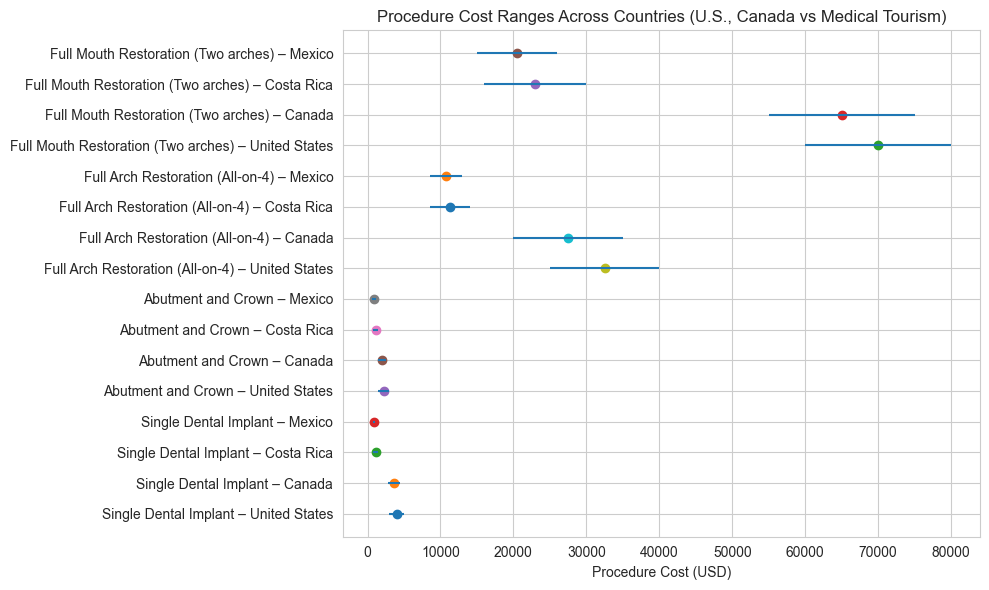

In [29]:
# -----------------------------
# 2. Visualization: Cross-country cost range comparison
# -----------------------------

plt.figure(figsize=(10,6))

for i, row in df.iterrows():
    plt.hlines(
        y=i,
        xmin=row["Min_Cost"],
        xmax=row["Max_Cost"]
    )
    plt.scatter(row["Expected_Cost"], i)

plt.yticks(range(len(df)), df["Procedure"] + " – " + df["Country"])
plt.xlabel("Procedure Cost (USD)")
plt.title("Procedure Cost Ranges Across Countries (U.S., Canada vs Medical Tourism)")
plt.tight_layout()
plt.show()


part3


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 定义 sponsor 的时间估计
data = [
    # Procedure, Category, Time_Value, Unit
    ("Single Dental Implant", "US Wait (clinical)", 3, "months"),
    ("Single Dental Implant", "Canada Wait (clinical)", 4, "months"),
    ("Single Dental Implant", "Costa Rica onsite", 7, "days"),
    ("Single Dental Implant", "Mexico onsite", 7, "days"),

    ("Abutment and Crown", "US Wait (clinical)", 2, "months"),
    ("Abutment and Crown", "Canada Wait (clinical)", 2.5, "months"),
    ("Abutment and Crown", "Costa Rica onsite", 7, "days"),
    ("Abutment and Crown", "Mexico onsite", 7, "days"),

    ("Full Arch Restoration", "US Wait (clinical)", 4, "months"),
    ("Full Arch Restoration", "Canada Wait (clinical)", 4, "months"),
    ("Full Arch Restoration", "Costa Rica onsite", 10, "days"),
    ("Full Arch Restoration", "Mexico onsite", 10, "days"),

    ("Full Mouth Restoration", "US Wait (clinical)", 6, "months"),
    ("Full Mouth Restoration", "Canada Wait (clinical)", 6, "months"),
    ("Full Mouth Restoration", "Costa Rica onsite", 10, "days"),
    ("Full Mouth Restoration", "Mexico onsite", 10, "days"),
]

df_time = pd.DataFrame(data, columns=[
    "Procedure", "Category", "Time_Value", "Unit"
])


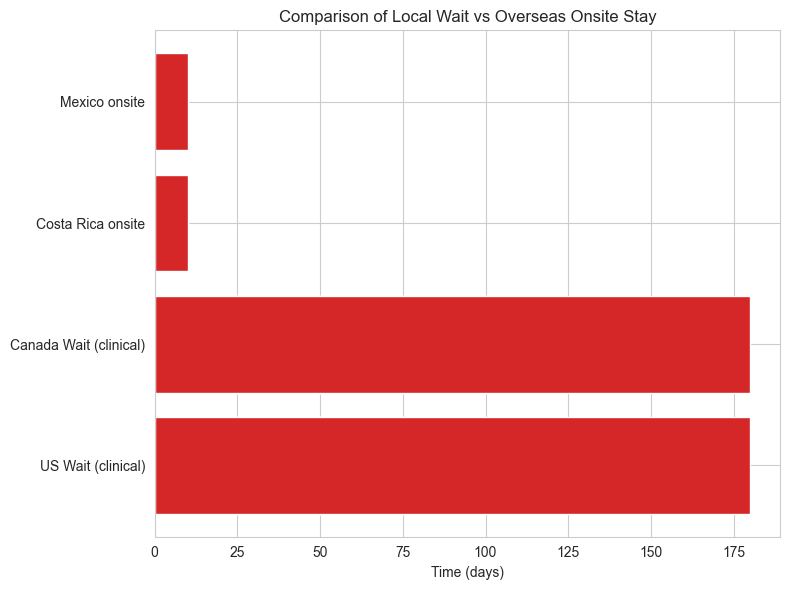

In [31]:
import numpy as np
df_plot = df_time.copy()

# 把 months 转成 days for对比
df_plot["Time_Days"] = np.where(
    df_plot["Unit"] == "months",
    df_plot["Time_Value"] * 30,
    df_plot["Time_Value"]
)

plt.figure(figsize=(8,6))
for proc in df_plot["Procedure"].unique():
    sub = df_plot[df_plot["Procedure"] == proc]
    plt.barh(sub["Category"], sub["Time_Days"], label=proc)

plt.xlabel("Time (days)")
plt.title("Comparison of Local Wait vs Overseas Onsite Stay")
plt.tight_layout()
plt.show()


part4


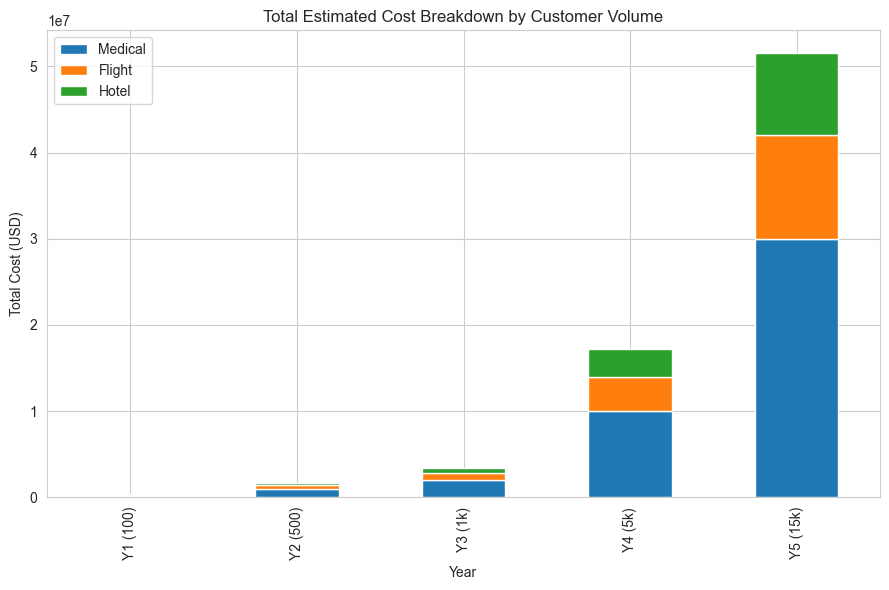

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Year": ["Y1 (100)", "Y2 (500)", "Y3 (1k)", "Y4 (5k)", "Y5 (15k)"],
    "Medical": [200000, 1000000, 2000000, 10000000, 30000000],
    "Flight": [80000, 400000, 800000, 4000000, 12000000],
    "Hotel": [64000, 320000, 640000, 3200000, 9600000],
}

df = pd.DataFrame(data).set_index("Year")

df.plot(kind="bar", stacked=True, figsize=(9,6))
plt.ylabel("Total Cost (USD)")
plt.title("Total Estimated Cost Breakdown by Customer Volume")
plt.tight_layout()
plt.show()


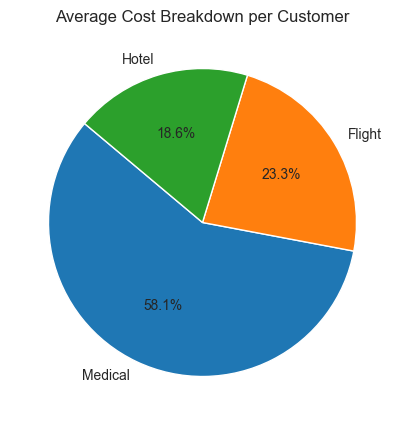

In [33]:
labels = ["Medical", "Flight", "Hotel"]
values = [2000, 800, 640]

plt.figure(figsize=(5,5))
plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=140)
plt.title("Average Cost Breakdown per Customer")
plt.show()


part5


Detail shape: (26, 8)
Summary shape: (10, 6)

Missing values in detail:
 Category       0
Subcategory    0
Year0          0
Year1          0
Year2          0
Year3          0
Year4          0
Year5          0
dtype: int64

Any negative values in detail? False

All-zero subcategories (Y1–Y5):


,Category,Subcategory,Year1,Year2,Year3,Year4,Year5
13,Marketing & Customer Acquisition,Referral Programs & Discounts,0,0,0,0,0



Reconciliation table (summary vs detail):


,Category,Year1_summary,Year2_summary,Year3_summary,Year4_summary,Year5_summary,Year1_detail,Year2_detail,Year3_detail,Year4_detail,Year5_detail,Year1_diff,Year2_diff,Year3_diff,Year4_diff,Year5_diff
0,Customer Support & Concierge,125000,250000,340000,360000,540000,125000,250000,340000,360000,540000,0,0,0,0,0
1,"Legal, Compliance, and Insurance",15000,15000,30000,35000,40000,15000,15000,30000,35000,40000,0,0,0,0,0
2,Marketing & Customer Acquisition,10000,35000,80000,120000,175000,10000,35000,80000,120000,175000,0,0,0,0,0
3,Miscellaneous Expenses,120000,360000,480000,120000,240000,120000,360000,480000,120000,240000,0,0,0,0,0
4,Office & Administrative Expenses,70000,70000,160000,320000,480000,70000,70000,160000,320000,480000,0,0,0,0,0
5,Partnerships & Vendor Costs,130000,260000,1010000,1320000,1590000,130000,260000,1010000,1320000,1590000,0,0,0,0,0
6,Staffing Costs,400000,700000,1520000,1720000,2200000,400000,700000,1520000,1720000,2200000,0,0,0,0,0
7,Technology & Platform Development,70000,140000,280000,340000,460000,70000,140000,280000,340000,460000,0,0,0,0,0
8,Total Patients Cost,344000,1720000,3440000,17200000,51600000,344000,1720000,3440000,17200000,51600000,0,0,0,0,0


Max abs diff for Year1: 0
Max abs diff for Year2: 0
Max abs diff for Year3: 0
Max abs diff for Year4: 0
Max abs diff for Year5: 0

CONFIRM: Detail-to-summary reconciliation within tolerance? True


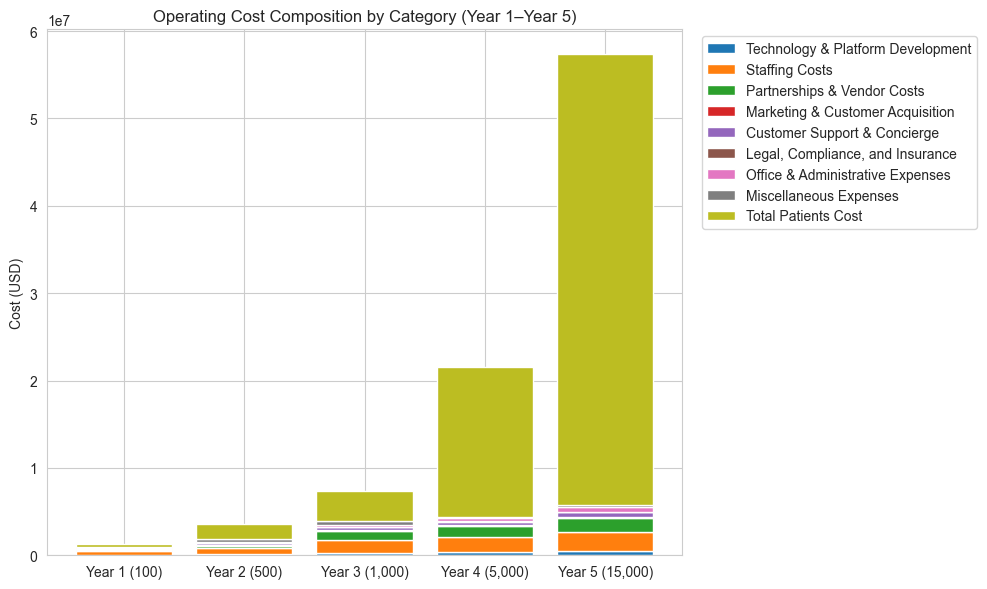

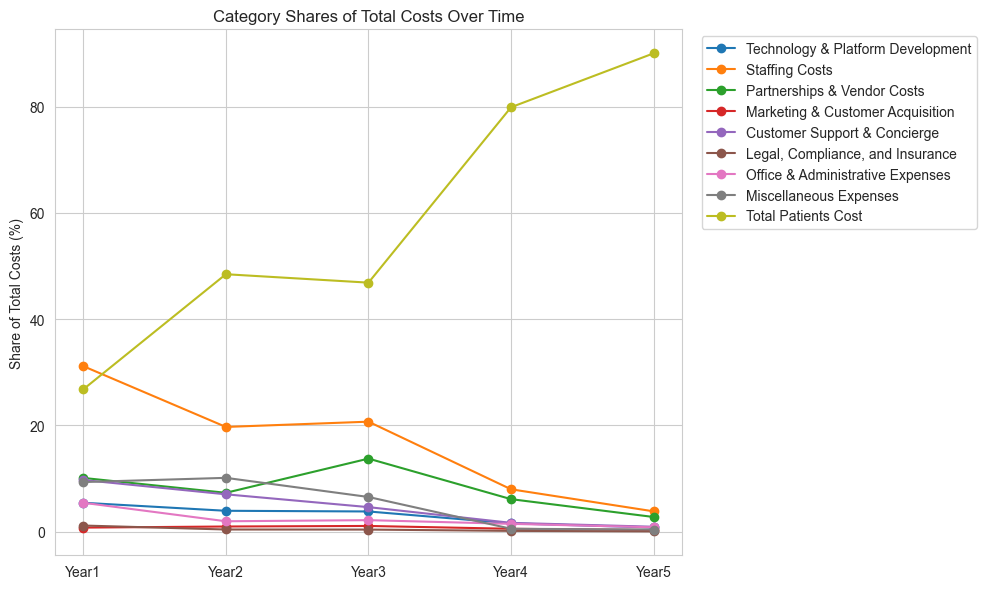

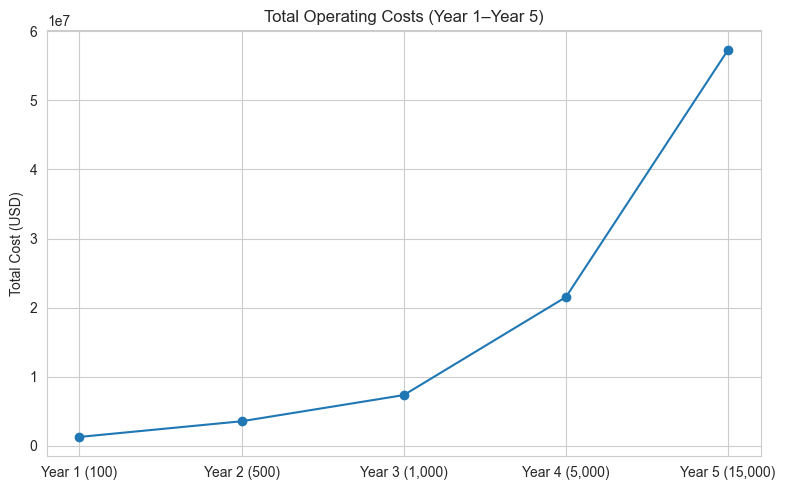

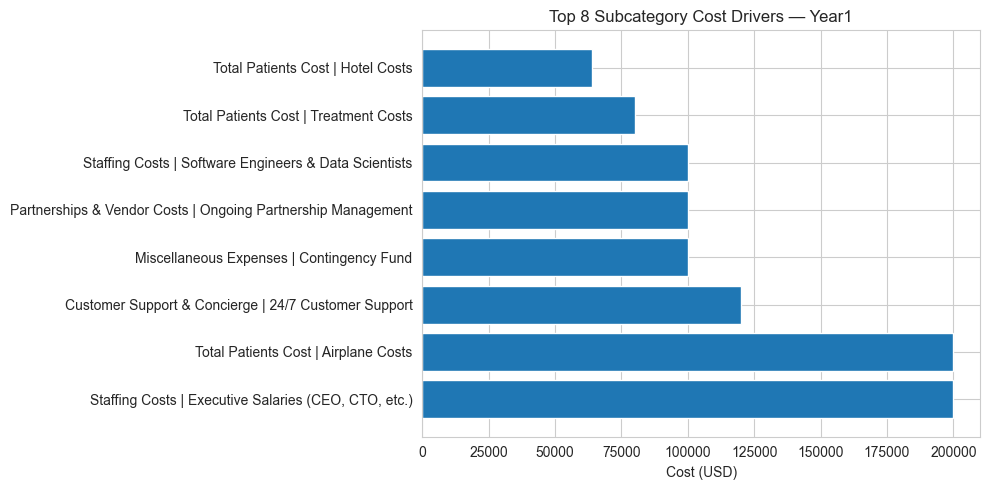

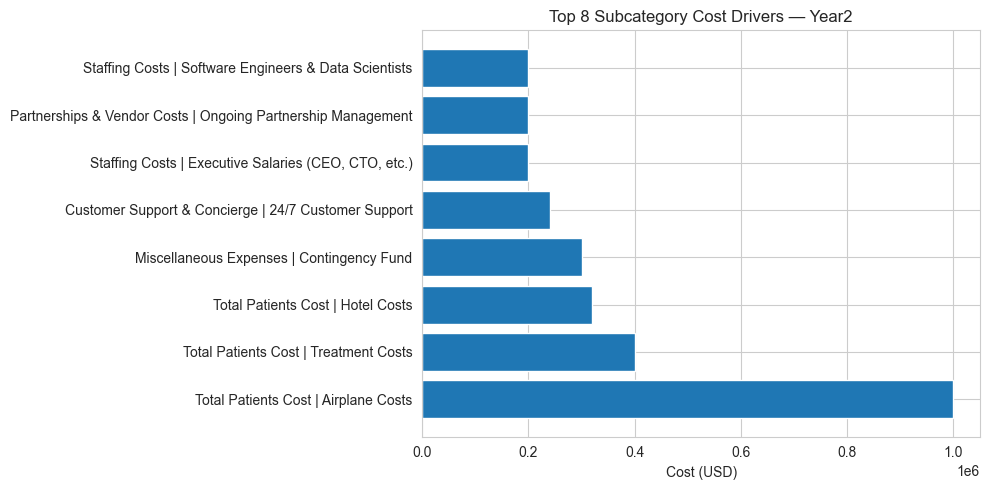

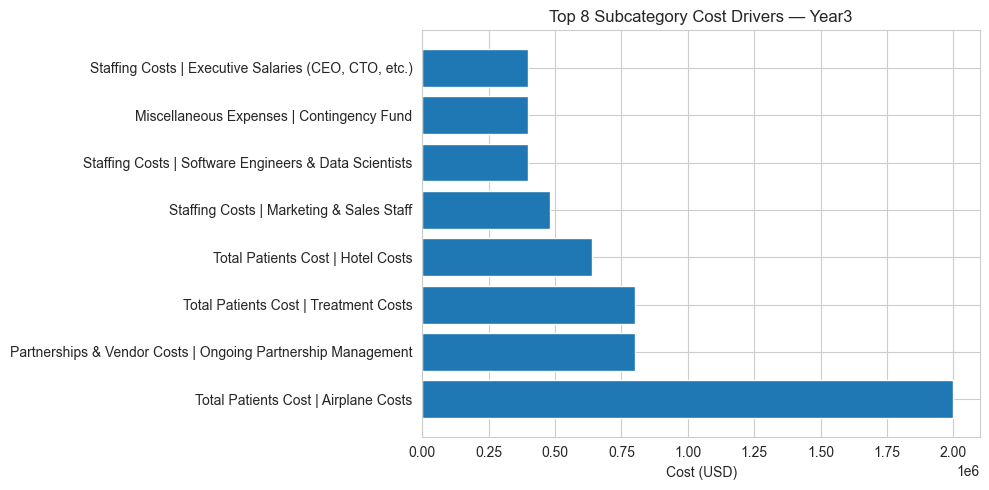

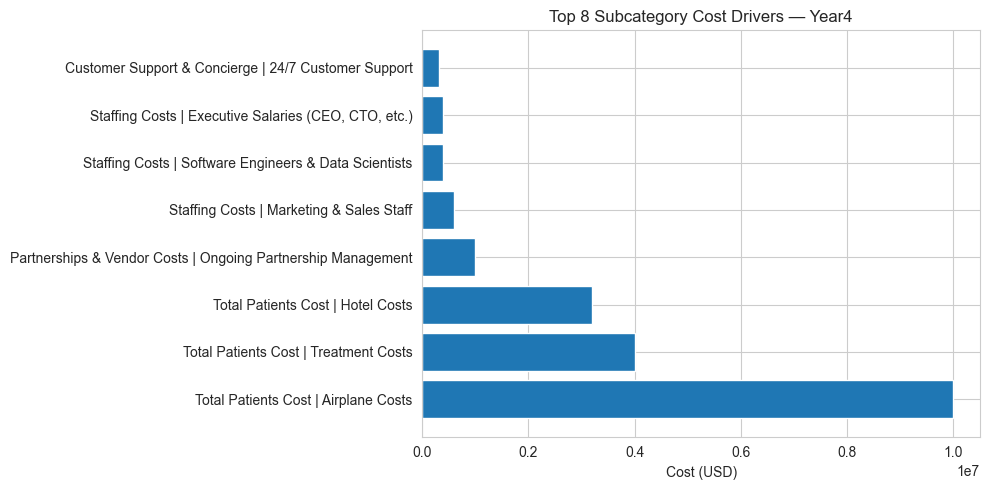

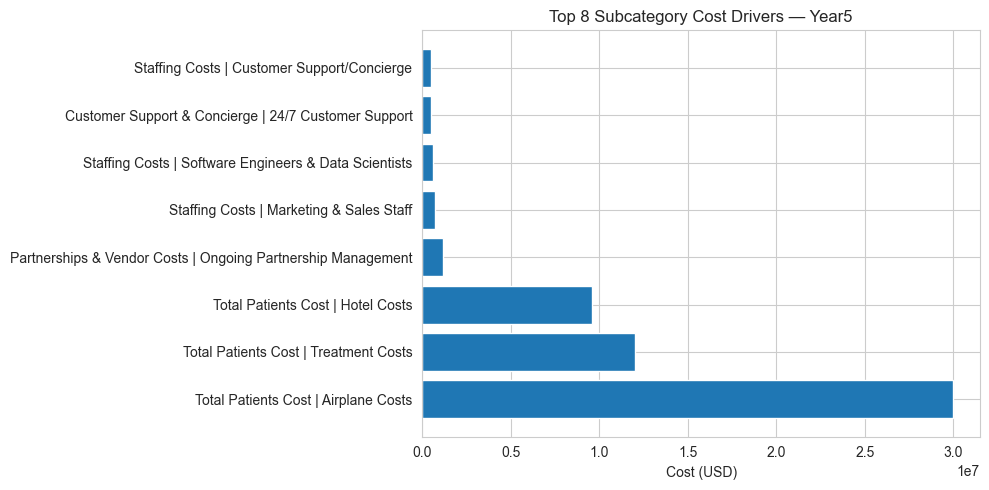


FLAG ITEMS (needs attention):
1. Contingency Fund is set to $0 in Year 4–Year 5; verify risk coverage assumptions at scale.
2. Referral Programs & Discounts are $0 across all years; confirm whether referrals are intentionally excluded from GTM budget.
3. Patient-related costs dominate Year 5 (~90.0% of total). Clarify whether these are pass-through costs or company-borne expenses.
4. Cloud Hosting & Storage appears to plateau in later years; verify scaling assumptions with higher customer volume.

CONFIRM cleaning/prep worked as expected:
- No missing values introduced in the structured DataFrames.
- All costs are non-negative.
- Detail-to-summary reconciliation check executed (see recon_ok above).


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0) Basic setup
# -----------------------------
YEARS = ["Year1", "Year2", "Year3", "Year4", "Year5"]
YEAR_LABELS = ["Year 1 (100)", "Year 2 (500)", "Year 3 (1,000)", "Year 4 (5,000)", "Year 5 (15,000)"]


# -----------------------------
# 1) Table B: Summary table (Category x Year)
#    (from your screenshot)
# -----------------------------
summary_rows = [
    ("Technology & Platform Development",  70000,   140000,   280000,    340000,    460000),
    ("Staffing Costs",                    400000,   700000,  1520000,   1720000,   2200000),
    ("Partnerships & Vendor Costs",       130000,   260000,  1010000,   1320000,   1590000),
    ("Marketing & Customer Acquisition",   10000,    35000,    80000,    120000,    175000),
    ("Customer Support & Concierge",      125000,   250000,   340000,    360000,    540000),
    ("Legal, Compliance, and Insurance",   15000,    15000,    30000,     35000,     40000),
    ("Office & Administrative Expenses",   70000,    70000,   160000,    320000,    480000),
    ("Miscellaneous Expenses",            120000,   360000,   480000,    120000,    240000),
    ("Total Patients Cost",               344000,  1720000,  3440000,  17200000,  51600000),
    ("Total Costs",                      1284000,  3550000,  7340000,  21535000,  57325000),
]

df_summary = pd.DataFrame(summary_rows, columns=["Category"] + YEARS)
df_summary


# -----------------------------
# 2) Table A: Detailed table (Subcategory x Year0–Year5)
#    (from your screenshot; edit numbers if your Excel differs)
# -----------------------------
detail_rows = [
    # Category, Subcategory, Year0, Year1, Year2, Year3, Year4, Year5
    ("Technology & Platform Development", "Initial Development (AI, website, app)", 10000, 10000, 20000, 40000, 80000, 160000),
    ("Technology & Platform Development", "Ongoing Maintenance & Updates",            5000,  5000, 10000, 20000, 40000,  80000),
    ("Technology & Platform Development", "Cloud Hosting & Storage",                  5000,  5000, 10000, 20000, 20000,  20000),
    ("Technology & Platform Development", "AI Licensing/Development",                50000, 50000,100000,200000,200000, 200000),

    ("Staffing Costs", "Executive Salaries (CEO, CTO, etc.)",                       100000,200000,200000,400000,400000, 400000),
    ("Staffing Costs", "Software Engineers & Data Scientists",                      100000,100000,200000,400000,400000, 600000),
    ("Staffing Costs", "Marketing & Sales Staff",                                    60000, 60000,180000,480000,600000, 720000),
    ("Staffing Costs", "Customer Support/Concierge",                                 40000, 40000,120000,240000,320000, 480000),

    ("Partnerships & Vendor Costs", "Medical Partnerships (setup, legal, travel)",   10000, 10000, 20000, 80000,120000, 150000),
    ("Partnerships & Vendor Costs", "Ongoing Partnership Management",               100000,100000,200000,800000,1000000,1200000),
    ("Partnerships & Vendor Costs", "Travel Vendor Partnerships (setup)",            10000, 10000, 20000, 60000,100000, 120000),
    ("Partnerships & Vendor Costs", "Ongoing Travel Partnership Management",         10000, 10000, 20000, 70000,100000, 120000),

    ("Marketing & Customer Acquisition", "Digital Marketing (SEO, paid ads, email)",  5000,  5000, 20000, 40000, 60000, 100000),
    ("Marketing & Customer Acquisition", "Referral Programs & Discounts",                0,     0,     0,     0,     0,      0),
    ("Marketing & Customer Acquisition", "Public Relations (PR) & Events",            5000,  5000, 15000, 40000, 60000,  75000),

    ("Customer Support & Concierge", "24/7 Customer Support",                        40000,120000,240000,320000,320000, 480000),
    ("Customer Support & Concierge", "Concierge Services",                             5000,  5000, 10000, 20000, 40000,  60000),

    ("Legal, Compliance, and Insurance", "Legal Counsel",                              5000,  5000,  5000, 10000, 15000,  20000),
    ("Legal, Compliance, and Insurance", "Insurance",                                 10000, 10000, 10000, 20000, 20000,  20000),

    ("Office & Administrative Expenses", "Office Rent",                                5000, 60000, 60000,120000,240000, 360000),
    ("Office & Administrative Expenses", "Operational Tools (CRM, accounting, etc.)", 10000, 10000, 10000, 40000, 80000, 120000),

    ("Miscellaneous Expenses", "Additional Travel Costs",                             20000, 20000, 60000, 80000,120000, 240000),
    ("Miscellaneous Expenses", "Contingency Fund",                                   100000,100000,300000,400000,     0,      0),

    ("Total Patients Cost", "Hotel Costs",                                                0,  64000, 320000, 640000, 3200000,  9600000),
    ("Total Patients Cost", "Airplane Costs",                                             0, 200000,1000000,2000000,10000000, 30000000),
    ("Total Patients Cost", "Treatment Costs",                                            0,  80000, 400000, 800000, 4000000, 12000000),
]

df_detail = pd.DataFrame(detail_rows, columns=["Category","Subcategory","Year0"] + YEARS)
df_detail


# -----------------------------
# 3) EDA 1: Basic checks (structure, missing, non-negativity)
# -----------------------------
print("Detail shape:", df_detail.shape)
print("Summary shape:", df_summary.shape)
print("\nMissing values in detail:\n", df_detail.isna().sum())
print("\nAny negative values in detail?", (df_detail[["Year0"] + YEARS] < 0).any().any())

# Identify all-zero subcategories across forecast years
df_detail["AllZero_Y1_Y5"] = (df_detail[YEARS].sum(axis=1) == 0)
print("\nAll-zero subcategories (Y1–Y5):")
display(df_detail.loc[df_detail["AllZero_Y1_Y5"], ["Category","Subcategory"] + YEARS])


# -----------------------------
# 4) EDA 2: Reconcile detail -> category totals vs summary table
# -----------------------------
detail_cat = df_detail.groupby("Category")[YEARS].sum().reset_index()

# Merge to compare (exclude Total Costs line because it's derived)
summary_cat_only = df_summary[~df_summary["Category"].isin(["Total Costs"])].copy()
compare = pd.merge(summary_cat_only, detail_cat, on="Category", how="outer", suffixes=("_summary","_detail"))

for y in YEARS:
    compare[f"{y}_diff"] = compare[f"{y}_summary"] - compare[f"{y}_detail"]

print("\nReconciliation table (summary vs detail):")
display(compare[["Category"] + [f"{y}_summary" for y in YEARS] + [f"{y}_detail" for y in YEARS] + [f"{y}_diff" for y in YEARS]])

# Quick pass/fail check for reconciliation (tolerance 1 dollar)
tol = 1
recon_ok = True
for y in YEARS:
    max_abs = compare[f"{y}_diff"].abs().max()
    print(f"Max abs diff for {y}: {max_abs}")
    recon_ok = recon_ok and (max_abs <= tol)

print("\nCONFIRM: Detail-to-summary reconciliation within tolerance?", recon_ok)


# -----------------------------
# 5) EDA 3: Composition analysis (category shares over time)
# -----------------------------
# Remove Total Costs row for share calc; also remove Total Patients Cost if you want platform-only view
df_cat = df_summary[~df_summary["Category"].isin(["Total Costs"])].copy()

# Build total per year from summary "Total Costs" line if present
total_costs_row = df_summary[df_summary["Category"]=="Total Costs"]
if not total_costs_row.empty:
    totals = total_costs_row[YEARS].iloc[0]
else:
    totals = df_cat[YEARS].sum()

shares = df_cat.set_index("Category")[YEARS].div(totals, axis=1) * 100
shares


# -----------------------------
# 6) Visualization 1: Stacked bar (Category composition by year)
# -----------------------------
plot_cat = df_cat.set_index("Category")[YEARS].copy()

plt.figure(figsize=(10,6))
bottom = np.zeros(len(YEARS))

x = np.arange(len(YEARS))
for cat in plot_cat.index:
    vals = plot_cat.loc[cat].values.astype(float)
    plt.bar(x, vals, bottom=bottom, label=cat)
    bottom += vals

plt.xticks(x, YEAR_LABELS, rotation=0)
plt.ylabel("Cost (USD)")
plt.title("Operating Cost Composition by Category (Year 1–Year 5)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# -----------------------------
# 7) Visualization 2: Category share (%) over time
# -----------------------------
plt.figure(figsize=(10,6))
for cat in shares.index:
    plt.plot(YEARS, shares.loc[cat].values, marker="o", label=cat)

plt.ylabel("Share of Total Costs (%)")
plt.title("Category Shares of Total Costs Over Time")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# -----------------------------
# 8) Visualization 3: Total cost scaling line
# -----------------------------
total_line = df_summary[df_summary["Category"]=="Total Costs"][YEARS].iloc[0].values.astype(float)

plt.figure(figsize=(8,5))
plt.plot(YEARS, total_line, marker="o")
plt.xticks(YEARS, YEAR_LABELS)
plt.ylabel("Total Cost (USD)")
plt.title("Total Operating Costs (Year 1–Year 5)")
plt.tight_layout()
plt.show()


# -----------------------------
# 9) Visualization 4: Top subcategory drivers per year (detail)
# -----------------------------
def top_drivers(df_detail, year_col, top_n=8):
    tmp = df_detail[["Category","Subcategory",year_col]].copy()
    tmp = tmp.sort_values(year_col, ascending=False).head(top_n)
    return tmp

for y in YEARS:
    top = top_drivers(df_detail, y, top_n=8)
    plt.figure(figsize=(10,5))
    plt.barh(top["Category"] + " | " + top["Subcategory"], top[y].values.astype(float))
    plt.title(f"Top {len(top)} Subcategory Cost Drivers — {y}")
    plt.xlabel("Cost (USD)")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 10) Flags: automatic attention items
# -----------------------------
flags = []

# Contingency drops to 0 later years
cont = df_detail[df_detail["Subcategory"].str.contains("Contingency", case=False, na=False)]
if not cont.empty:
    if (cont[["Year4","Year5"]] == 0).all().all():
        flags.append("Contingency Fund is set to $0 in Year 4–Year 5; verify risk coverage assumptions at scale.")

# Referral always 0
ref = df_detail[df_detail["Subcategory"].str.contains("Referral", case=False, na=False)]
if not ref.empty and (ref[YEARS].sum(axis=1) == 0).all():
    flags.append("Referral Programs & Discounts are $0 across all years; confirm whether referrals are intentionally excluded from GTM budget.")

# Patient costs dominate later years
patient = df_summary[df_summary["Category"]=="Total Patients Cost"]
total  = df_summary[df_summary["Category"]=="Total Costs"]
if (not patient.empty) and (not total.empty):
    patient_share_y5 = float(patient["Year5"].iloc[0]) / float(total["Year5"].iloc[0]) * 100
    if patient_share_y5 >= 80:
        flags.append(f"Patient-related costs dominate Year 5 (~{patient_share_y5:.1f}% of total). Clarify whether these are pass-through costs or company-borne expenses.")

# Cloud hosting plateaus
cloud = df_detail[df_detail["Subcategory"].str.contains("Cloud Hosting", case=False, na=False)]
if not cloud.empty:
    vals = cloud[YEARS].iloc[0].values.astype(float)
    if vals[-1] == vals[-2] == vals[-3]:
        flags.append("Cloud Hosting & Storage appears to plateau in later years; verify scaling assumptions with higher customer volume.")

print("\nFLAG ITEMS (needs attention):")
for i, f in enumerate(flags, 1):
    print(f"{i}. {f}")

print("\nCONFIRM cleaning/prep worked as expected:")
print("- No missing values introduced in the structured DataFrames.")
print("- All costs are non-negative.")
print("- Detail-to-summary reconciliation check executed (see recon_ok above).")
